# Matthew Harry Indriadi | 24/532723/PA/22527 | Implementation of Object Detection for Vehicles
Import OpenCV and NumPy for image processing and array operations.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import urllib.request

# Download YOLOv4-tiny Assets
We need three files for YOLO: the weights, the network config, and the class names.

In [2]:
YOLO_DIR = "yolo_assets"
os.makedirs(YOLO_DIR, exist_ok=True)

urls = {
    "yolov4-tiny.weights": "https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v4_pre/yolov4-tiny.weights",
    "yolov4-tiny.cfg": "https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4-tiny.cfg",
    "coco.names": "https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names"
}

paths = {}
for filename, url in urls.items():
    paths[filename] = os.path.join(YOLO_DIR, filename)
    if not os.path.exists(paths[filename]):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, paths[filename])
print("YOLO assets are ready.")

YOLO assets are ready.


# Load the Model and Classes

Load COCO class names (YOLO is trained on 80 classes; we only want vehicles)

In [3]:
with open(paths["coco.names"], "r") as f:
    classes = [line.strip() for line in f.readlines()]

vehicle_classes = ["car", "motorbike", "bus", "truck"]

net = cv2.dnn.readNet(paths["yolov4-tiny.weights"], paths["yolov4-tiny.cfg"])
model = cv2.dnn_DetectionModel(net)

model.setInputParams(size=(416, 416), scale=1/255, swapRB=True)

# Load the Image

In [4]:
image_path = 'road_image.jpg'

if not os.path.exists(image_path):
    print(f"Downloading sample image...")
    urllib.request.urlretrieve("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/street.jpg", image_path)

image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError("Image not found. Check the path.")

# Run Detection
Set a confidence threshold (0.4 means 40% sure) and NMS threshold (0.3 overlap)

In [5]:
confThreshold = 0.4
nmsThreshold = 0.3

print("Running YOLO detection...")
classIds, confidences, boxes = model.detect(image, confThreshold, nmsThreshold)

Running YOLO detection...


# Filter and Draw Results

In [6]:
output_img = image.copy()
detected_count = 0

if len(classIds) > 0:
    for classId, confidence, box in zip(classIds.flatten(), confidences.flatten(), boxes):
        class_name = classes[classId]
        
        if class_name in vehicle_classes:
            detected_count += 1
            x, y, w, h = box
            
            cv2.rectangle(output_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
            
            label = f"{class_name}: {confidence:.2f}"
            cv2.putText(
                output_img, label,
                (x, max(y - 10, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2
            )

# Display the Output

Total vehicles detected: 13


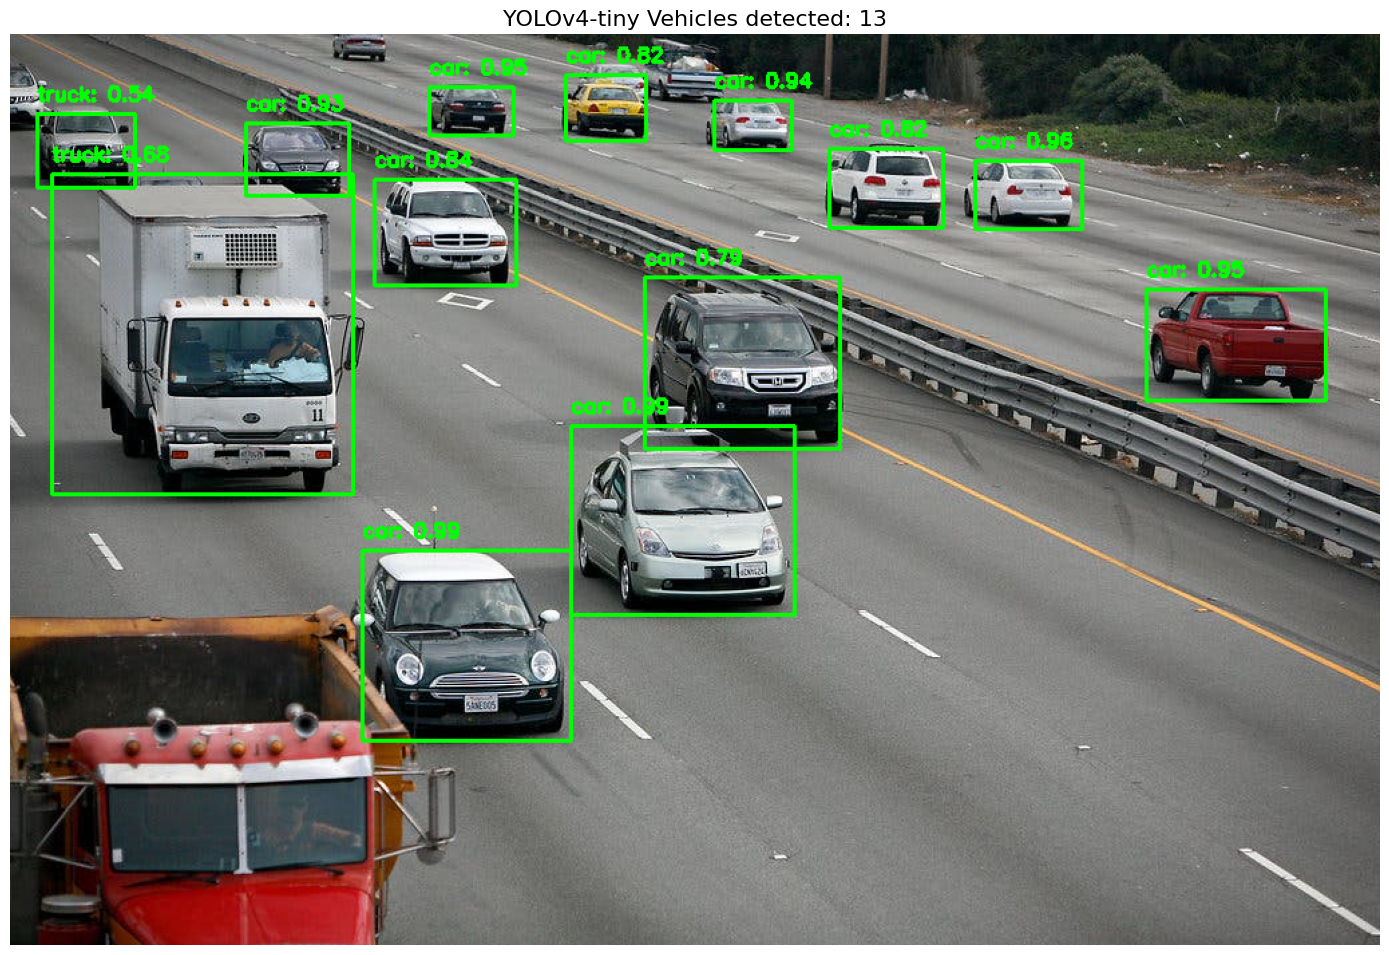

In [7]:
print(f"Total vehicles detected: {detected_count}")

plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.title(f'YOLOv4-tiny Vehicles detected: {detected_count}', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()